Raw neural shape: (106315, 175)
Raw syllables shape: (106315,)
PC data shape: (106315, 10)
Explained variance ratio: [0.02983362 0.02559309 0.0239983  0.02116554 0.01891012 0.01624032
 0.01583899 0.01523398 0.0146709  0.01392858]
Cumulative explained variance: [0.02983362 0.05542672 0.07942502 0.10059056 0.11950068 0.135741
 0.15157998 0.16681395 0.18148486 0.19541344]
Using device: cuda
Epoch 000 | Loss: 3.456546
Epoch 020 | Loss: 1.371458
Epoch 040 | Loss: 0.179823
Epoch 060 | Loss: 0.062183
Epoch 080 | Loss: 0.033009
Epoch 100 | Loss: 0.024970
Epoch 120 | Loss: 0.021689
Epoch 140 | Loss: 0.020264
Epoch 160 | Loss: 0.020028
Epoch 180 | Loss: 0.018429
Epoch 199 | Loss: 0.020124
Final predicted PC shape: (106314, 10)
Latent shape z_t: (106314, 128)
Embedding shape e_t: (106314, 16)
Baseline MSE (predict next PC = current PC): 0.009910969
Model MSE: 0.019877749


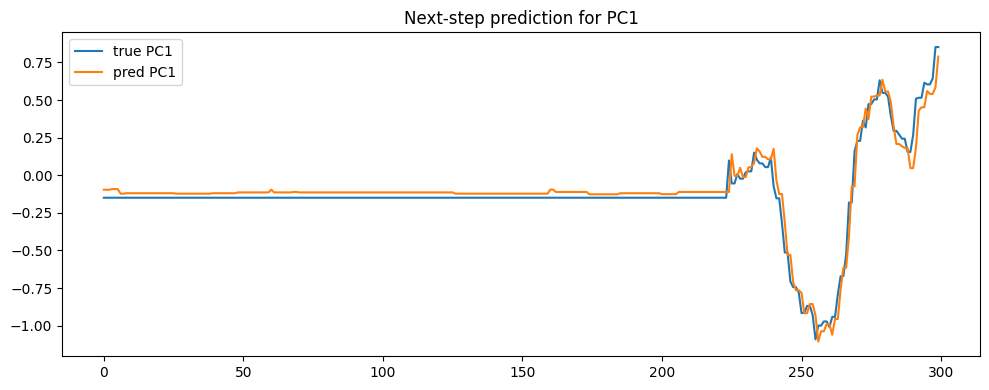

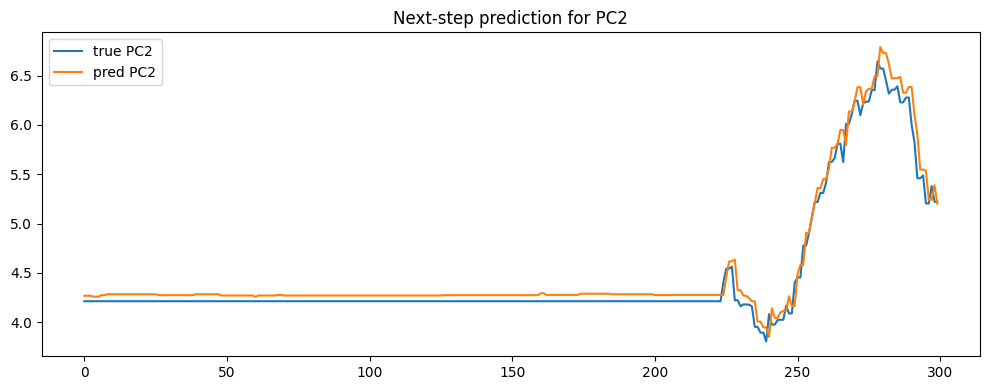

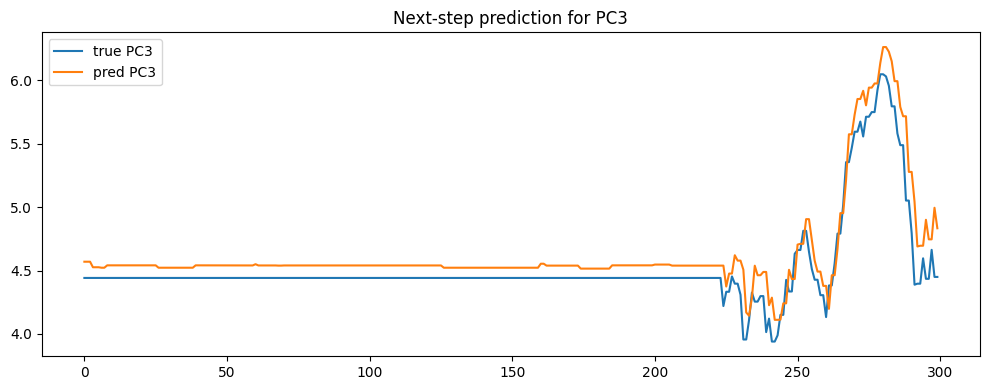

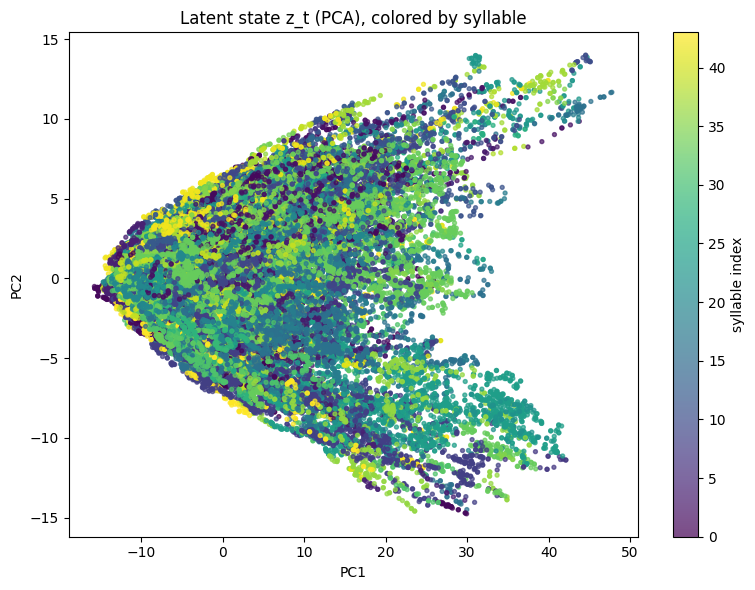

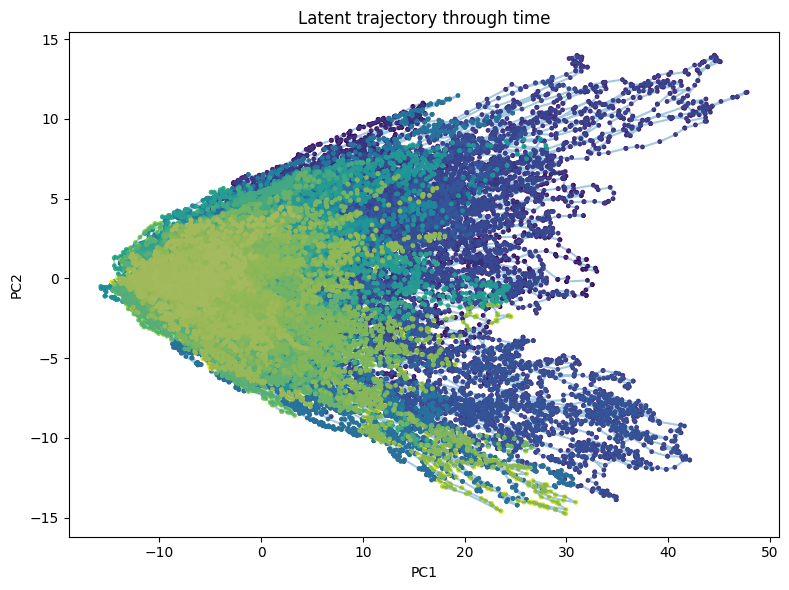

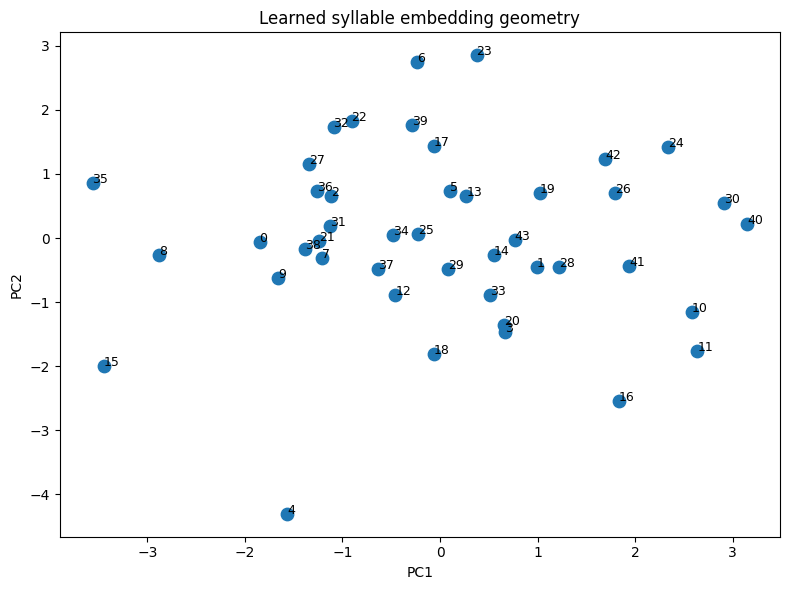

Done.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


class SyllablePCModel(nn.Module):
    def __init__(self, n_pcs, n_syllables, emb_dim=16, hidden_dim=128):
        super().__init__()

        self.syll_embedding = nn.Embedding(n_syllables, emb_dim)

        self.pc_encoder = nn.Sequential(
            nn.Linear(n_pcs, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim + emb_dim, hidden_dim),
            nn.ReLU(),
        )

        self.predict_next_pc = nn.Linear(hidden_dim, n_pcs)

    def forward(self, x_t, syll_t):
        # x_t: [batch, n_pcs]
        # syll_t: [batch]

        e_t = self.syll_embedding(syll_t)   # [batch, emb_dim]
        h_t = self.pc_encoder(x_t)          # [batch, hidden_dim]
        z_t = self.fusion(torch.cat([h_t, e_t], dim=-1))
        x_next_pred = self.predict_next_pc(z_t)

        return x_next_pred, z_t, e_t


def visualize_latent_space(model, pc_data, syllables, device="cpu"):
    model.eval()

    syllables = np.asarray(syllables).squeeze()

    if pc_data.ndim != 2:
        raise ValueError(f"Expected pc_data shape [T, n_pcs], got {pc_data.shape}")
    if syllables.ndim != 1:
        raise ValueError(f"Expected syllables shape [T], got {syllables.shape}")
    if len(pc_data) != len(syllables):
        raise ValueError("pc_data and syllables must have the same length")

    unique_sylls = np.unique(syllables)
    syll_to_idx = {s: i for i, s in enumerate(unique_sylls)}
    syllables_idx = np.array([syll_to_idx[s] for s in syllables], dtype=np.int64)

    x_t_np = pc_data[:-1].astype(np.float32)
    syll_t_np = syllables_idx[:-1]

    x_t = torch.tensor(x_t_np, dtype=torch.float32, device=device)
    syll_t = torch.tensor(syll_t_np, dtype=torch.long, device=device)

    with torch.no_grad():
        _, z_t, e_t = model(x_t, syll_t)

    z_np = z_t.cpu().numpy()
    e_np = e_t.cpu().numpy()

    z_2d = PCA(n_components=2).fit_transform(z_np)

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        z_2d[:, 0],
        z_2d[:, 1],
        c=syll_t_np,
        s=8,
        alpha=0.7,
    )
    plt.colorbar(sc, label="syllable index")
    plt.title("Latent state z_t (PCA), colored by syllable")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.plot(z_2d[:, 0], z_2d[:, 1], alpha=0.4)
    plt.scatter(z_2d[:, 0], z_2d[:, 1], c=np.arange(len(z_2d)), s=6)
    plt.title("Latent trajectory through time")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    syllable_means = []
    syllable_labels = []

    for k in np.unique(syll_t_np):
        mask = syll_t_np == k
        syllable_means.append(e_np[mask].mean(axis=0))
        syllable_labels.append(k)

    syllable_means = np.array(syllable_means)
    syll_emb_2d = PCA(n_components=2).fit_transform(syllable_means)

    plt.figure(figsize=(8, 6))
    plt.scatter(syll_emb_2d[:, 0], syll_emb_2d[:, 1], s=80)

    for i, label in enumerate(syllable_labels):
        plt.text(syll_emb_2d[i, 0], syll_emb_2d[i, 1], str(label), fontsize=9)

    plt.title("Learned syllable embedding geometry")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()

    return z_np, z_2d, e_np


def main():
    # -------------------------
    # Load data
    # -------------------------
    neural = np.load('/home/maria/Science/data/spontaneous_behaviors/made_data/neural_rec.npy')
    syllables = np.load('/home/maria/Science/data/spontaneous_behaviors/made_data/moseq_syllables_aux.npy')

    print("Raw neural shape:", neural.shape)
    print("Raw syllables shape:", syllables.shape)

    if neural.ndim != 2:
        raise ValueError(f"Expected neural to have shape [T, n_neurons], got {neural.shape}")

    syllables = np.asarray(syllables).squeeze()
    if syllables.ndim != 1:
        raise ValueError(f"Expected syllables to have shape [T], got {syllables.shape}")

    if len(neural) != len(syllables):
        raise ValueError(
            f"Length mismatch: neural has {len(neural)} timepoints, "
            f"but syllables has {len(syllables)} entries"
        )

    # If your array is [neurons, T], uncomment this:
    # neural = neural.T

    # -------------------------
    # Standardize neural data before PCA
    # -------------------------
    scaler = StandardScaler()
    neural_scaled = scaler.fit_transform(neural)

    # -------------------------
    # PCA on neural data
    # -------------------------
    n_pcs = 10
    pca = PCA(n_components=n_pcs)
    neural_pcs = pca.fit_transform(neural_scaled)

    print("PC data shape:", neural_pcs.shape)
    print("Explained variance ratio:", pca.explained_variance_ratio_)
    print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))

    # -------------------------
    # Remap syllable labels to 0...K-1
    # -------------------------
    unique_sylls = np.unique(syllables)
    syll_to_idx = {s: i for i, s in enumerate(unique_sylls)}
    syllables_idx = np.array([syll_to_idx[s] for s in syllables], dtype=np.int64)

    # -------------------------
    # One-step dataset in PC space
    # -------------------------
    x_t_np = neural_pcs[:-1].astype(np.float32)
    x_tp1_np = neural_pcs[1:].astype(np.float32)
    syll_t_np = syllables_idx[:-1]

    # -------------------------
    # Torch tensors
    # -------------------------
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    x_t = torch.tensor(x_t_np, dtype=torch.float32, device=device)
    x_tp1 = torch.tensor(x_tp1_np, dtype=torch.float32, device=device)
    syll_t = torch.tensor(syll_t_np, dtype=torch.long, device=device)

    # -------------------------
    # Model
    # -------------------------
    num_syllables = len(unique_sylls)

    model = SyllablePCModel(
        n_pcs=n_pcs,
        n_syllables=num_syllables,
        emb_dim=16,
        hidden_dim=128,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    # -------------------------
    # Training
    # -------------------------
    n_epochs = 200

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()

        x_next_pred, z_t, e_t = model(x_t, syll_t)
        loss = loss_fn(x_next_pred, x_tp1)

        loss.backward()
        optimizer.step()

        if epoch % 20 == 0 or epoch == n_epochs - 1:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.6f}")

    # -------------------------
    # Final evaluation
    # -------------------------
    model.eval()
    with torch.no_grad():
        x_next_pred, z_t, e_t = model(x_t, syll_t)

    pred = x_next_pred.cpu().numpy()
    true = x_tp1.cpu().numpy()
    z_np = z_t.cpu().numpy()
    e_np = e_t.cpu().numpy()

    print("Final predicted PC shape:", pred.shape)
    print("Latent shape z_t:", z_np.shape)
    print("Embedding shape e_t:", e_np.shape)

    # -------------------------
    # Baseline comparison
    # -------------------------
    baseline_pred = x_t.cpu().numpy()

    baseline_mse = np.mean((baseline_pred - true) ** 2)
    model_mse = np.mean((pred - true) ** 2)

    print("Baseline MSE (predict next PC = current PC):", baseline_mse)
    print("Model MSE:", model_mse)

    # -------------------------
    # Plot first few PCs
    # -------------------------
    n_plot_pcs = min(3, n_pcs)

    for pc_idx in range(n_plot_pcs):
        plt.figure(figsize=(10, 4))
        plt.plot(true[:300, pc_idx], label=f"true PC{pc_idx+1}")
        plt.plot(pred[:300, pc_idx], label=f"pred PC{pc_idx+1}")
        plt.legend()
        plt.title(f"Next-step prediction for PC{pc_idx+1}")
        plt.tight_layout()
        plt.show()

    # -------------------------
    # Visualize latent space
    # -------------------------
    visualize_latent_space(
        model=model,
        pc_data=neural_pcs,
        syllables=syllables,
        device=device,
    )

    print("Done.")

    return model, pca, scaler


model, pca_model, scaler_model = main()